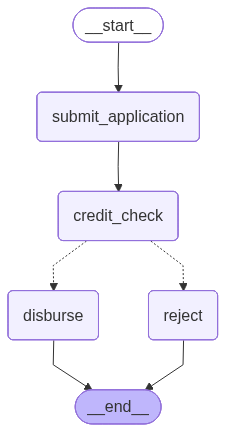


===== WORKFLOW LOG =====
Loan application submitted by Premchandar
Credit Score: 750 - Loan Approved
Loan amount disbursed to Premchandar

===== FINAL STATE =====
{'customer_name': 'Premchandar', 'credit_score': 750, 'approved': True, 'log': ['Loan application submitted by Premchandar', 'Credit Score: 750 - Loan Approved', 'Loan amount disbursed to Premchandar']}


In [1]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Dict, Any
from IPython.display import Image, display

# Define State

class LoanState(TypedDict):
    customer_name: str
    credit_score: int
    approved: bool
    log: list[str]

# Nodes

def submit_application(state: Dict[str, Any]) -> Dict[str, Any]:
    log = state["log"] + [
        f"Loan application submitted by {state['customer_name']}"
    ]
    return {**state, "log": log}

def check_credit(state: Dict[str, Any]) -> Dict[str, Any]:

    approved = state["credit_score"] >= 700

    if approved:
        msg = f"Credit Score: {state['credit_score']} - Loan Approved"
    else:
        msg = f"Credit Score: {state['credit_score']} - Loan Rejected"

    return {
        **state,
        "approved": approved,
        "log": state["log"] + [msg]
    }

def disburse_loan(state: Dict[str, Any]) -> Dict[str, Any]:
    log = state["log"] + [
        f"Loan amount disbursed to {state['customer_name']}"
    ]
    return {**state, "log": log}

def reject_loan(state: Dict[str, Any]) -> Dict[str, Any]:
    log = state["log"] + [
        f"Loan request rejected for {state['customer_name']}"
    ]
    return {**state, "log": log}

# Routing Function

def route_decision(state: Dict[str, Any]) -> str:
    return "disburse" if state["approved"] else "reject"

# Build Graph

builder = StateGraph(LoanState)

builder.add_node("submit_application", submit_application)
builder.add_node("credit_check", check_credit)
builder.add_node("disburse", disburse_loan)
builder.add_node("reject", reject_loan)

builder.set_entry_point("submit_application")

builder.add_edge("submit_application", "credit_check")

builder.add_conditional_edges(
    "credit_check",
    route_decision,
    {
        "disburse": "disburse",
        "reject": "reject"
    }
)

builder.add_edge("disburse", END)
builder.add_edge("reject", END)

graph = builder.compile()

# Visualize Graph

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization failed:", e)

# Execute Workflow

result = graph.invoke({
    "customer_name": "Premchandar",
    "credit_score": 750,
    "approved": False,
    "log": []
})

# Print Results

print("\n===== WORKFLOW LOG =====")

for step in result["log"]:
    print(step)

print("\n===== FINAL STATE =====")
print(result)